Integrantes:
Jesús Márquez,
Mariana Ramírez

Sección: MINERIA DE DATOS_003D

## Introducción al Análisis de Exoplanetas

Este notebook tiene como objetivo principal la preparación y análisis inicial de un conjunto de datos de exoplanetas de la NASA.


El proceso comienza con la carga de los datos desde un archivo CSV y una exploración detallada para comprender su estructura, tipos de datos y la presencia de valores nulos.

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 500) #capability

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/nasa_exoplanet_intelligence.csv")

In [ ]:
df.head()

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
0,Kepler-1167 b,Kepler-1167,1,1,Transit,2016.0,Kepler,1.003934,1.710000,3.570,...,298.302660,47.693965,0,Super-Earth,False,False,False,Far(500-2kpc),K-type,Short(1-10d)
1,Kepler-1740 b,Kepler-1740,1,1,Transit,2021.0,Kepler,8.172400,3.323214,11.000,...,293.873663,38.922455,0,Mini-Neptune,False,False,True,Far(500-2kpc),G-type(Sun-like),Short(1-10d)
2,Kepler-1581 b,Kepler-1581,1,1,Transit,2016.0,Kepler,6.283855,0.800000,0.437,...,287.371320,39.603623,0,Sub-Earth,False,False,False,Mid(100-500pc),F-type,Short(1-10d)
3,Kepler-644 b,Kepler-644,1,1,Transit,2016.0,Kepler,3.173917,3.150000,10.100,...,295.475702,43.493112,0,Mini-Neptune,False,False,False,Far(500-2kpc),F-type,Short(1-10d)
4,Kepler-1752 b,Kepler-1752,1,1,Transit,2021.0,Kepler,56.358501,4.540605,18.700,...,290.854140,51.222743,0,Neptune-like,False,False,True,Far(500-2kpc),G-type(Sun-like),Medium(10-100d)


In [ ]:
df.tail()

,planet_name,host_star,n_stars,n_planets,discovery_method,disc_year,disc_facility,orbital_period_days,planet_radius_earth,planet_mass_earth,...,ra,dec,controversial_flag,planet_type,habitable_zone_flag,multi_planet_system,is_recent_discovery,dist_category,star_type,orbital_period_cat
6145,KMT-2024-BLG-1870L b,KMT-2024-BLG-1870L,1,1,Microlensing,2026.0,KMTNet,NaN,13.800,336.898111,...,272.465333,-26.882889,0,Gas Giant,False,False,True,Distant(2k+pc),Unknown,Unknown
6146,TOI-2267 b,TOI-2267 A,2,3,Transit,2025.0,Transiting Exoplanet Survey Satellite (TESS),2.28909,1.000,0.972000,...,65.061496,84.900824,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6147,TOI-813 b,TOI-813,1,1,Transit,2020.0,Transiting Exoplanet Survey Satellite (TESS),83.89110,6.710,36.400000,...,72.694010,-60.905461,0,Gas Giant,False,False,True,Mid(100-500pc),G-type(Sun-like),Medium(10-100d)
6148,LHS 1903 b,LHS 1903,1,4,Transit,2026.0,Transiting Exoplanet Survey Satellite (TESS),2.15551,1.382,3.280000,...,107.865826,48.327933,0,Super-Earth,False,True,True,Nearby(<100pc),M-type(Red Dwarf),Short(1-10d)
6149,TOI-375 d,TOI-375,1,3,Radial Velocity,2026.0,Multiple Observatories,297.90000,13.600,445.595427,...,47.149903,-77.383327,0,Gas Giant,False,True,True,Mid(100-500pc),G-type(Sun-like),Long(100-365d)


In [ ]:
df.columns

Index(['planet_name', 'host_star', 'n_stars', 'n_planets', 'discovery_method',
       'disc_year', 'disc_facility', 'orbital_period_days',
       'planet_radius_earth', 'planet_mass_earth', 'equilibrium_temp_k',
       'orbital_eccentricity', 'semi_major_axis_au', 'star_temp_k',
       'star_radius_sun', 'star_mass_sun', 'star_age_gyr',
       'star_surface_gravity', 'star_metallicity', 'dist_from_earth_pc',
       'star_vmag', 'ra', 'dec', 'controversial_flag', 'planet_type',
       'habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery',
       'dist_category', 'star_type', 'orbital_period_cat'],
      dtype='object')

In [ ]:
df.shape

(6150, 31)

In [ ]:
df.describe().count().count() #solo a las columnas numericas

np.int64(20)

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6150 entries, 0 to 6149
Data columns (total 31 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   planet_name           6150 non-null   object 
 1   host_star             6150 non-null   object 
 2   n_stars               6150 non-null   int64  
 3   n_planets             6150 non-null   int64  
 4   discovery_method      6150 non-null   object 
 5   disc_year             6149 non-null   float64
 6   disc_facility         6150 non-null   object 
 7   orbital_period_days   5816 non-null   float64
 8   planet_radius_earth   6100 non-null   float64
 9   planet_mass_earth     6119 non-null   float64
 10  equilibrium_temp_k    4587 non-null   float64
 11  orbital_eccentricity  5212 non-null   float64
 12  semi_major_axis_au    5834 non-null   float64
 13  star_temp_k           5860 non-null   float64
 14  star_radius_sun       5836 non-null   float64
 15  star_mass_sun        

In [ ]:
df['planet_name'].value_counts()

,count
planet_name,
TOI-375 d,1
Kepler-1167 b,1
Kepler-1740 b,1
Kepler-1581 b,1
Kepler-644 b,1
...,...
K2-19 b,1
HD 168746 b,1
Kepler-1101 b,1


In [ ]:
df['host_star'].value_counts()

,count
host_star,
KOI-351,8
TRAPPIST-1,7
HD 110067,6
TOI-178,6
HIP 41378,6
...,...
HD 20868,1
K2-150,1
TOI-2570,1


In [ ]:
df['discovery_method'].value_counts()

,count
discovery_method,
Transit,4517
Radial Velocity,1182
Microlensing,275
Imaging,94
Transit Timing Variations,39
Eclipse Timing Variations,17
Orbital Brightness Modulation,9
Pulsar Timing,8
Astrometry,6


In [ ]:
df['disc_facility'].value_counts()

,count
disc_facility,
Kepler,2783
Transiting Exoplanet Survey Satellite (TESS),762
K2,549
Multiple Observatories,351
La Silla Observatory,302
W. M. Keck Observatory,194
KMTNet,134
SuperWASP,122
OGLE,110


In [ ]:
df['planet_type'].value_counts()

,count
planet_type,
Mini-Neptune,2148
Gas Giant,1734
Super-Earth,1185
Neptune-like,479
Super-Jupiter,324
Sub-Earth,230
Unknown,50


In [ ]:
df['dist_category'].value_counts()

,count
dist_category,
Far(500-2kpc),2252
Mid(100-500pc),2029
Nearby(<100pc),1524
Distant(2k+pc),318
Unknown,27


In [ ]:
df['star_type'].value_counts()

,count
star_type,
G-type(Sun-like),2669
K-type,1644
F-type,1075
M-type(Red Dwarf),423
Unknown,290
A-type,25
B-type,19
O-type,5


In [ ]:
df['orbital_period_cat'].value_counts()

,count
orbital_period_cat,
Short(1-10d),2588
Medium(10-100d),2083
Very-Long(365d+),642
Long(100-365d),346
Unknown,334
Ultra-Short(<1d),157


Posteriormente, se realiza una fase de limpieza de datos, donde se eliminan las filas con valores nulos para asegurar la integridad del conjunto de datos.

In [ ]:
df.isnull().sum()

,0
planet_name,0
host_star,0
n_stars,0
n_planets,0
discovery_method,0
disc_year,1
disc_facility,0
orbital_period_days,334
planet_radius_earth,50
planet_mass_earth,31


In [ ]:
df_limpio = df.dropna()

In [ ]:
df_limpio.isnull().sum()

,0
planet_name,0
host_star,0
n_stars,0
n_planets,0
discovery_method,0
disc_year,0
disc_facility,0
orbital_period_days,0
planet_radius_earth,0
planet_mass_earth,0


In [ ]:
df_limpio.to_csv("nasa_csv_limpio.csv")

 Las variables categóricas se transforman utilizando Binary Encoding para prepararlas para futuros modelos de aprendizaje automático, mientras que las columnas booleanas se convierten a formato numérico (0 y 1).

In [ ]:
pip install category_encoders

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

In [ ]:
# Using the cleaned DataFrame `df_limpio` for encoding to avoid issues with missing values.
# 3. Binary Encoding para 'planet_name' usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como las comunas
be = ce.BinaryEncoder(cols=['planet_name','host_star','discovery_method','disc_facility','planet_type','dist_category','star_type','orbital_period_cat'])
df_binary = be.fit_transform(df_limpio[['planet_name','host_star','discovery_method','disc_facility','planet_type','dist_category','star_type','orbital_period_cat']])

In [ ]:
#Con if como dijo el profe
cols_bool = ['habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery']

for col in cols_bool:
    df_limpio[col] = df_limpio[col].apply(lambda x: 1 if x == True else 0)

/tmp/ipykernel_5404/3576729550.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_limpio[col] = df_limpio[col].apply(lambda x: 1 if x == True else 0)


In [ ]:
#codigo para concatenar
cols_bool = ['habitable_zone_flag', 'multi_planet_system', 'is_recent_discovery']

df_final = pd.concat([df_limpio.drop(columns=['planet_name','host_star','discovery_method','disc_facility','planet_type','dist_category','star_type','orbital_period_cat']), df_binary], axis=1)


In [ ]:
df_final.isnull().sum()

,0
n_stars,0
n_planets,0
disc_year,0
orbital_period_days,0
planet_radius_earth,0
planet_mass_earth,0
equilibrium_temp_k,0
orbital_eccentricity,0
semi_major_axis_au,0
star_temp_k,0


In [ ]:
df_final.head()

,n_stars,n_planets,disc_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temp_k,orbital_eccentricity,semi_major_axis_au,star_temp_k,...,planet_type_2,dist_category_0,dist_category_1,dist_category_2,star_type_0,star_type_1,star_type_2,orbital_period_cat_0,orbital_period_cat_1,orbital_period_cat_2
0,1,1,2016.0,1.003934,1.710000,3.570,1419.0,0.0,0.01750,4971.0,...,1,0,0,1,0,0,1,0,0,1
2,1,1,2016.0,6.283855,0.800000,0.437,1108.0,0.0,0.06865,6022.0,...,0,0,1,0,0,1,0,0,0,1
3,1,1,2016.0,3.173917,3.150000,10.100,1655.0,0.0,0.04641,6747.0,...,1,0,0,1,0,1,0,0,0,1
4,1,1,2021.0,56.358501,4.540605,18.700,419.0,0.0,0.26980,5446.0,...,0,0,0,1,0,1,1,0,1,0
5,1,2,2014.0,4.807091,2.010000,4.700,1088.0,0.0,0.05600,5744.0,...,1,0,0,1,0,1,1,0,0,1


In [ ]:
df_final.shape

(3806, 68)

Finalmente, se genera un mapa de calor de correlación para visualizar las relaciones entre las variables numéricas, proporcionando una base sólida para análisis más profundos y la construcción de modelos.

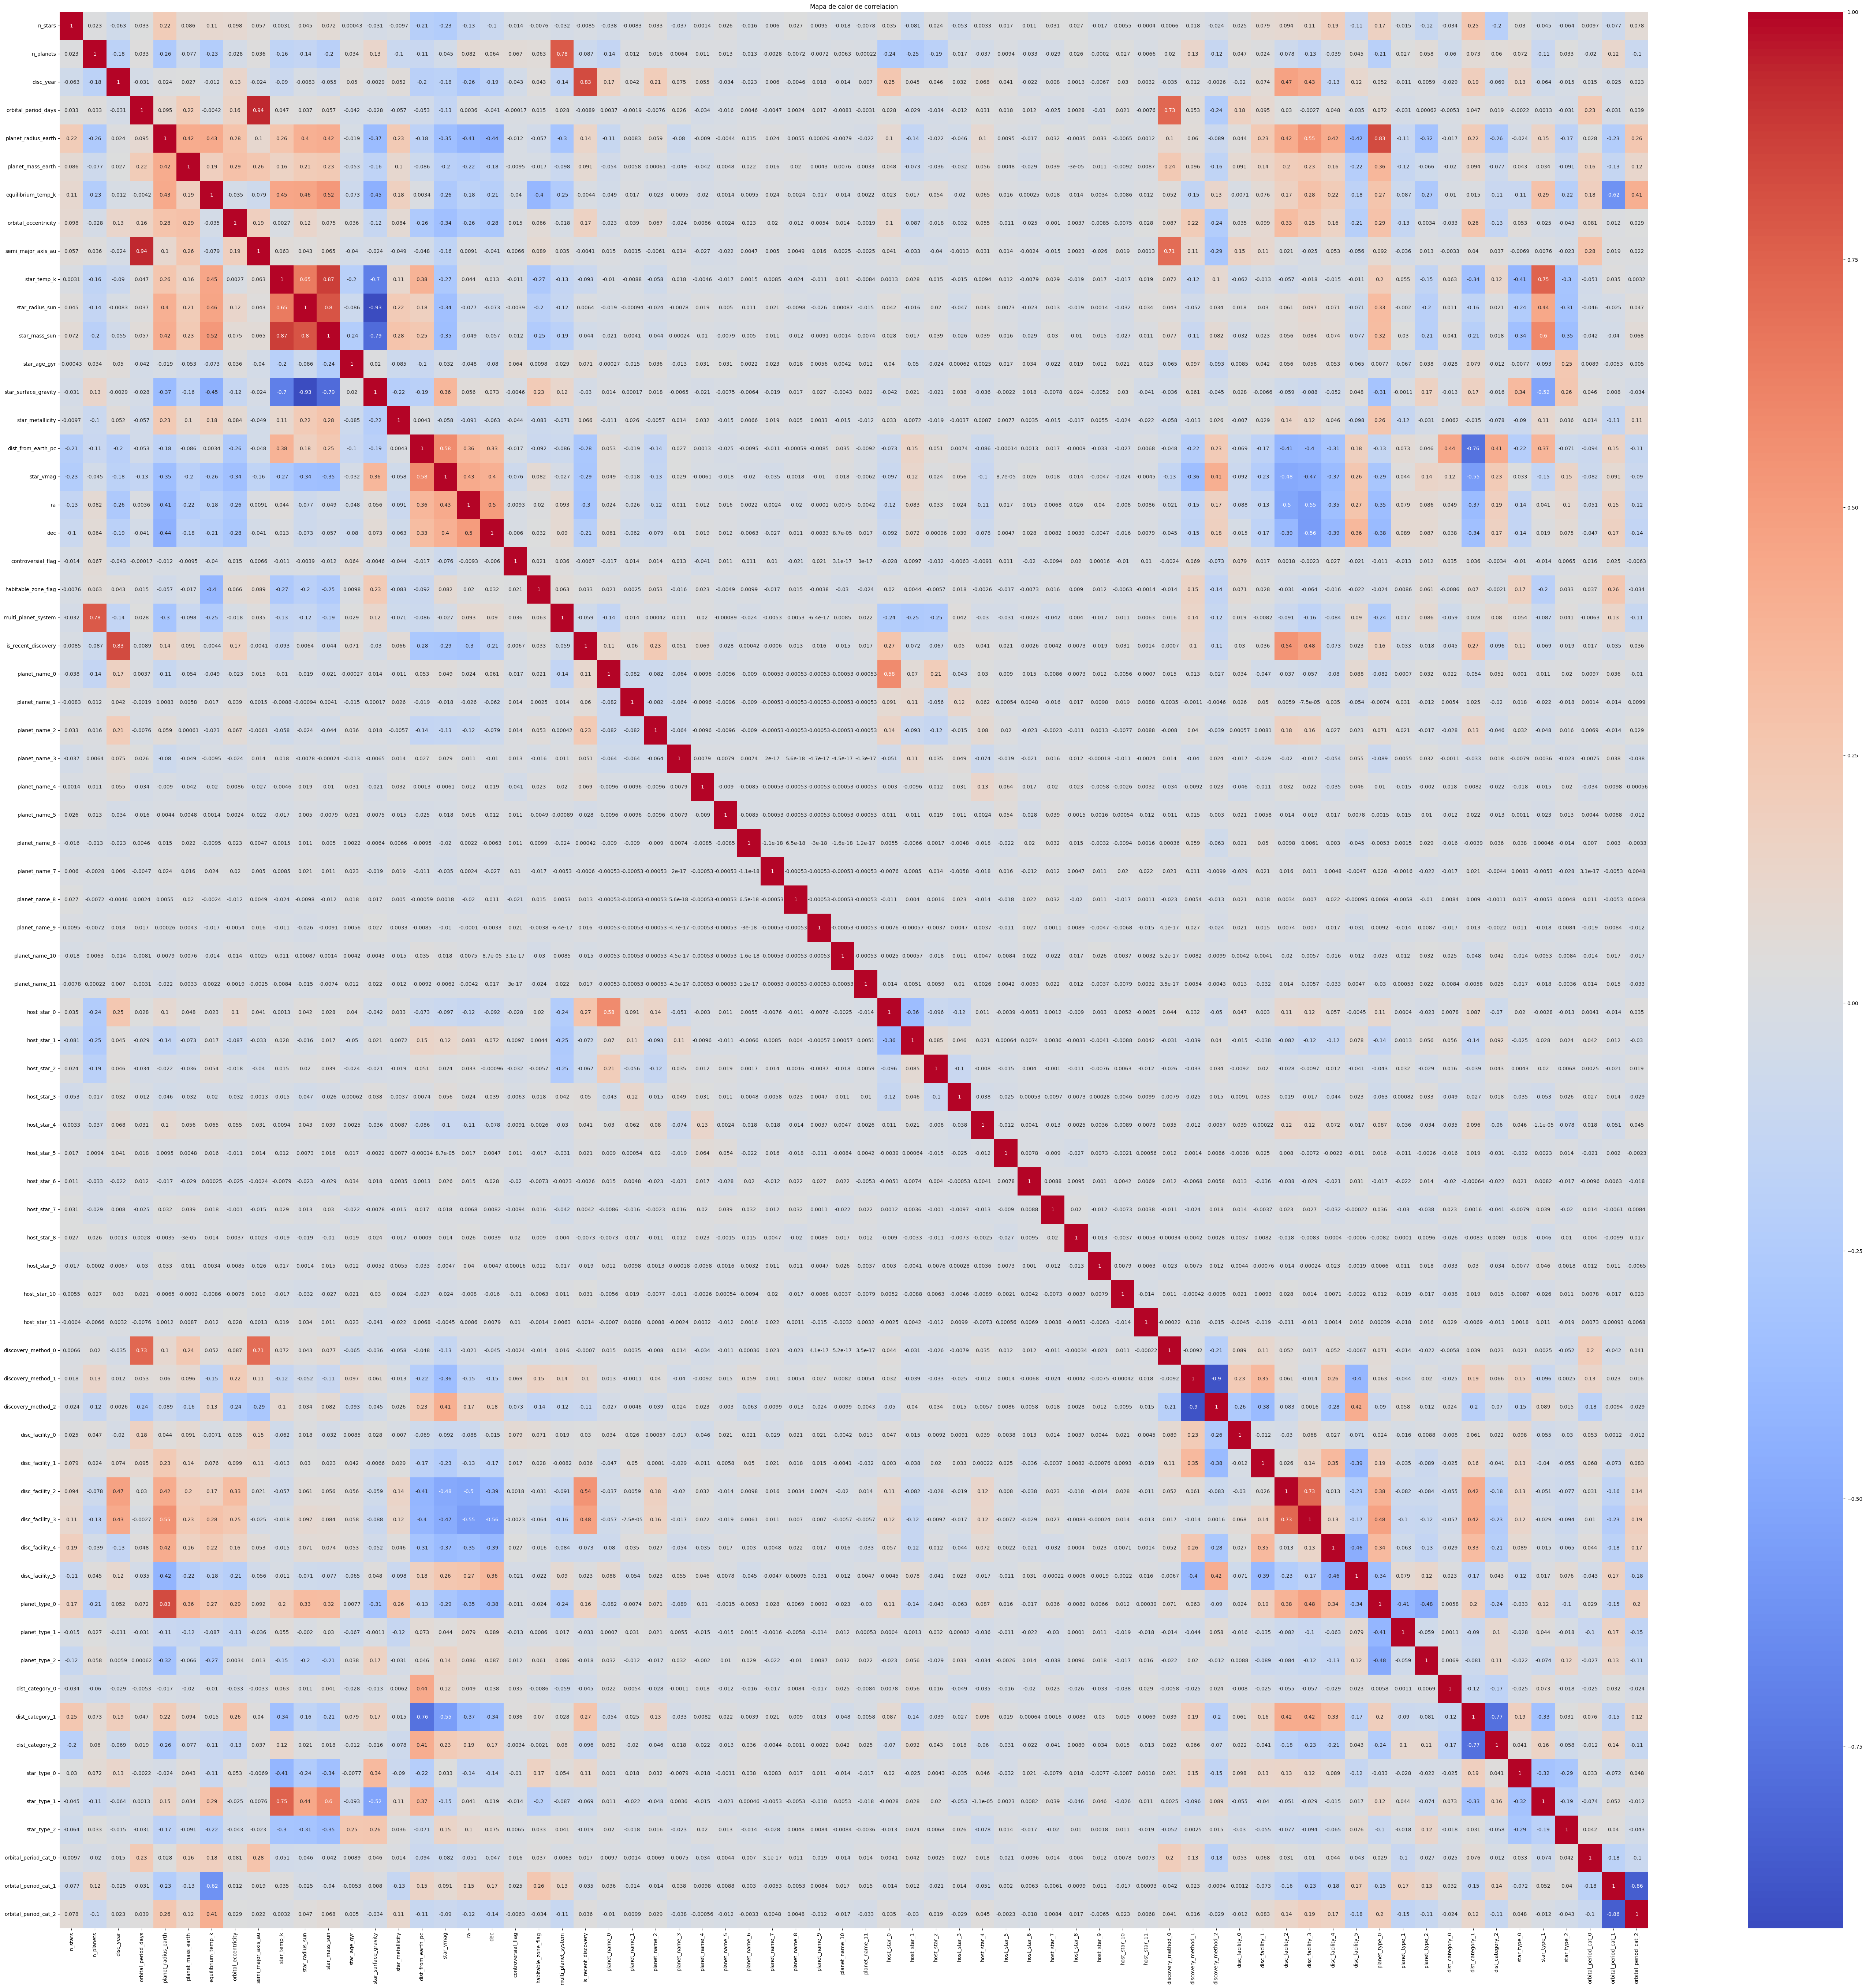

In [ ]:
corr = df_final.select_dtypes(include='number').corr() #correlacion

plt.figure(figsize=(70,68))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlacion")
plt.show()